In [1]:
import numpy as np
import xarray as xr

import cartopy
import matplotlib as mpl
import matplotlib.pyplot as plt

In [2]:
dataset_path = "E:/dataset"
forecast_ds = xr.open_dataset(f"{dataset_path}/mx_secihti_cicese_forecast_sst_nep_0p01deg_200501-203112_v1.nc")
forecast_ds

c:\Users\USER\anaconda3\lib\site-packages\xarray\backends\plugins.py:80: RuntimeWarning: Engine 'gini' loading failed:
No module named 'pooch'
  warnings.warn(f"Engine {name!r} loading failed:\n{ex}", RuntimeWarning)


<xarray.Dataset> Size: 16GB
Dimensions:       (time: 324, lat: 3501, lon: 3501)
Coordinates:
  * time          (time) datetime64[ns] 3kB 2005-01-01 2005-02-01 ... 2031-12-01
  * lat           (lat) float32 14kB 20.0 20.01 20.02 20.03 ... 54.98 54.99 55.0
  * lon           (lon) float32 14kB -140.0 -140.0 -140.0 ... -105.0 -105.0
Data variables:
    sst_forecast  (time, lat, lon) float32 16GB ...
Attributes: (12/14)
    title:               High-resolution SST forecast over the Northeast Paci...
    summary:             Monthly sea surface temperature (SST) forecast gener...
    institution:         SECIHTI / CICESE-UALP
    source:              GAM-based statistical SST forecast
    history:             Created on 2026-02-15T18:29:19.963027
    references:          
    ...                  ...
    lat_min:             20.0
    lat_max:             55.0
    lon_min:             -140.0
    lon_max:             -105.0
    time_start:          2005-01-01T00:00:00.000000000
    time_end:            2031-12-01T00:00:00.000000000

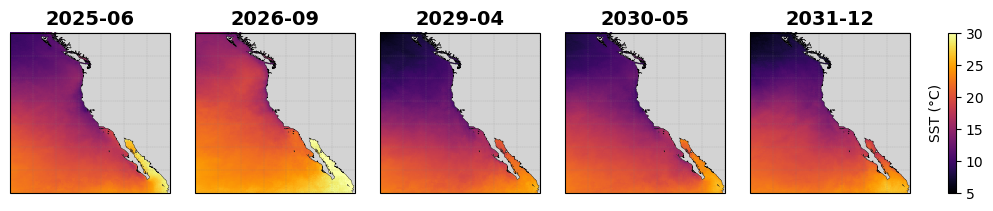

In [3]:
dates = ["2025-06-01","2026-09-01","2029-04-01","2030-05-01","2031-12-01"]

fig = plt.figure(figsize=(10, 2), constrained_layout=True)
cmap = mpl.cm.get_cmap("inferno")

for k in range(len(dates)):
    idx = np.where(forecast_ds.time.values == np.datetime64(dates[k]))[0][0]
    
    ax = fig.add_subplot(1, len(dates), k+1, projection=cartopy.crs.PlateCarree())
    land = cartopy.feature.NaturalEarthFeature('physical', 'land', scale="10m", edgecolor='k', facecolor=cartopy.feature.COLORS['land'])
    ax.add_feature(land, facecolor='lightgray', linewidth=0.25)
    gl = ax.gridlines(crs=cartopy.crs.PlateCarree(), draw_labels=False, linewidth=0.25, color='gray', alpha=0.5, linestyle='--')

    pc = ax.pcolor(forecast_ds.lon, forecast_ds.lat, forecast_ds.sst_forecast.sel(time=dates[k]).data, cmap=cmap, vmin=5, vmax=30)
    ax.set_title(dates[k][:7], fontweight="bold", fontsize=14)

cbar = fig.colorbar(pc, ax=fig.axes, pad=0.02)
cbar.set_label("SST (°C)")
cbar.ax.yaxis.set_label_position("left")
plt.show()